## LECTURE 2: ECG data pre-processing for Machine Learning
#### Instructor: Ishan Vatsaraj
#### Course: AI for Biomedical Signals

##### ------------------------------------------
#### STEP 1: SETUP & INSTALLATION
##### ------------------------------------------
##### We are installing:
##### - wfdb: To read the medical data format.
##### - neurokit2: The industry standard for biosignal processing.

In [1]:
print("Installing dependencies... (This may take a minute)")
!pip install -q wfdb neurokit2 matplotlib pandas scipy

import wfdb
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from scipy import signal
import os

import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")

Installing dependencies... (This may take a minute)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
Setup complete!


##### ------------------------------------------
#### STEP 2: DOWNLOAD & LOAD DATA
##### ------------------------------------------
##### We will download THREE patient records so you can compare them.
##### 00001: Normal Sinus Rhythm (Healthy-ish)
##### 00103: Sinus Tachycardia (Fast heart beat)
##### 00225: Sinus Tachycardia (Slow heart beat)

In [2]:
print("Downloading patient data...")
os.makedirs('data', exist_ok=True)
base_url = "https://physionet.org/files/ptb-xl/1.0.3/records100/00000/"
records = ["00001_lr", "00103_lr", "00225_lr"]

for r in records:
    !wget -q -O data/{r}.dat {base_url}{r}.dat
    !wget -q -O data/{r}.hea {base_url}{r}.hea
    print(f"Downloaded {r}")

# --- Change this variable to swap patients! ---
record_name = '00001_lr'

# Load the data
signals, fields = wfdb.rdsamp(f'data/{record_name}')
sampling_rate = fields['fs']
leads = fields['sig_name']
lead_index = 1  # Lead II
raw_signal = signals[:, lead_index]

print(f"\nLoaded Record: {record_name}")
print(f"Leads: {leads}")
print(f"Sampling Rate: {sampling_rate} Hz")

Downloaded 00001_lr
Downloaded 00103_lr
Downloaded 00225_lr

Loaded Record: 00001_lr
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Sampling Rate: 100 Hz


##### ------------------------------------------
#### STEP 3: VISUALIZE THE RAW (NOISY) SIGNAL
##### ------------------------------------------
##### Let's see what raw data actually looks like.

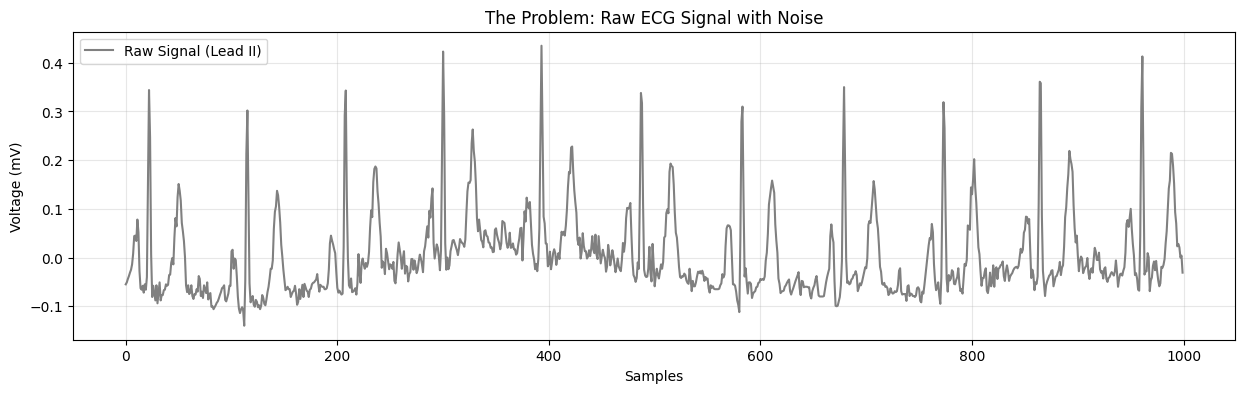

In [8]:
plt.figure(figsize=(15, 4))
plt.plot(raw_signal[:1000], color='grey', label='Raw Signal (Lead II)')
plt.title("The Problem: Raw ECG Signal with Noise")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What is Neurokit2?
NeuroKit2 is the industry-standard Python package for neurophysiological signal processing.
Instead of writing raw filters (scipy.signal.butter), Neurokit gives us high-level pipelines.

We will use two main functions:
1. `nk.ecg_clean()`: Removes noise (breathing, powerline).
2. `nk.ecg_peaks()`: Finds the R-peaks (heartbeats).

Docs: https://neuropsychology.github.io/NeuroKit/

##### ------------------------------------------
#### STEP 4: SIGNAL PROCESSING (Student Task)
##### ------------------------------------------
##### FUNCTION: nk.ecg_clean(ecg_signal, sampling_rate, method)
##### DOCS:
##### - 'ecg_signal': The raw array of voltage we loaded.
##### - 'sampling_rate': Vital! Filters work on time (Hz). If this is wrong, the filter breaks.
##### - 'method': We use "biosppy". It applies a 0.6-45Hz Bandpass filter.

--- Processing Signal ---
1000


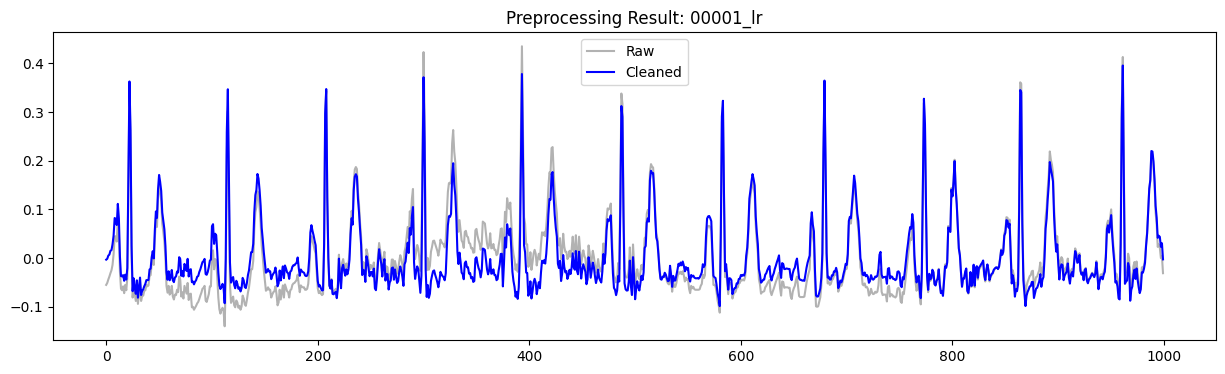

In [11]:
print("--- Processing Signal ---")

# ================= STUDENT CODE START =================
# TODO: Clean the signal using method='biosppy'
print(len(raw_signal))
clean_signal = nk.ecg_clean(raw_signal, sampling_rate=sampling_rate, method='biosppy') #TODO

# ================= STUDENT CODE END ===================

# Visualize Raw vs Clean
plt.figure(figsize=(15, 4))
plt.plot(raw_signal[:1000], color='grey', label='Raw', alpha=0.6)
plt.plot(clean_signal[:1000], color='blue', label='Cleaned')
plt.title(f"Preprocessing Result: {record_name}")
plt.legend()
plt.show()

##### ------------------------------------------
#### STEP 5: PEAK DETECTION (Student Task)
##### ------------------------------------------
##### FUNCTION: nk.ecg_peaks(ecg_cleaned, sampling_rate)
##### DOCS:
##### - 'ecg_cleaned': We must pass the CLEAN signal. Noise confuses the peak detector!
##### - RETURNS: A tuple (signals, info). 'info' is a dictionary containing the peak locations.

In [12]:
print("--- Finding Peaks ---")

# ================= STUDENT CODE START =================
# TODO: Find the R-peaks

_, r_peaks_dict = nk.ecg_peaks(clean_signal, sampling_rate=sampling_rate)

r_peaks = r_peaks_dict['ECG_R_Peaks']

# ================= STUDENT CODE END ===================

# Check our work
num_peaks = len(r_peaks)
print(f"Detected {num_peaks} R-peaks in this recording.")

# Quick Challenge: Calculate BPM
duration_minutes = (len(clean_signal) / sampling_rate) / 60
bpm = num_peaks / duration_minutes
print(f"Estimated Heart Rate: {bpm:.1f} BPM")

--- Finding Peaks ---
Detected 10 R-peaks in this recording.
Estimated Heart Rate: 60.0 BPM


##### ------------------------------------------
#### STEP 6: MANUAL FEATURE EXTRACTION (The Math)
##### ------------------------------------------
##### GOAL: Don't just trust a library. Let's calculate the metrics manually using NumPy.
##### 1. R-R Interval: Time between beats.
##### 2. BPM: 60 / R-R Interval.
##### 3. HRV (RMSSD): The standard measure of stress.

In [13]:
print("\n--- Calculating Features Manually ---")

# 1. Calculate RR-Intervals (in samples)
rr_samples = np.diff(r_peaks)

# 2. Convert to Seconds
rr_seconds = rr_samples / sampling_rate

# ================= STUDENT CODE START =================
# TODO: Calculate Heart Rate (BPM)
# Hint: BPM = 60 / average_rr_interval_in_seconds
# bpm = ...

bpm = 60 / np.mean(rr_seconds)

# TODO: Calculate RMSSD (Heart Rate Variability)
# Formula: Sqrt( Mean( Diff(RR_intervals)^2 ) )
# Hint: Use np.diff(), np.mean(), np.sqrt()
# diff_rr = ...
# rmssd = ...

diff_rr = np.diff(rr_seconds)
rmssd = np.sqrt(np.mean(diff_rr ** 2))

# ================= STUDENT CODE END ===================

print(f"Mean Heart Rate: {bpm:.2f} BPM")
print(f"HRV (RMSSD):     {rmssd:.4f} seconds")

# Clinical Interpretation Logic
if rmssd < 0.020:
    print("Interpretation: Low HRV (High Stress / Sympathetic Dominance)")
else:
    print("Interpretation: Normal/High HRV (Relaxed / Parasympathetic)")


--- Calculating Features Manually ---
Mean Heart Rate: 63.83 BPM
HRV (RMSSD):     0.0265 seconds
Interpretation: Normal/High HRV (Relaxed / Parasympathetic)


##### ------------------------------------------
#### STEP 6.1: AUTOMATED FEATURE EXTRACTION (The "Magic Button")
##### ------------------------------------------
##### INTRO:
##### In Step 6, we calculated BPM and RMSSD manually to understand the math.
##### But in real research, we need hundreds of features (Entropy, Poincaré plots, etc.).
##### NeuroKit2 has a function that does this instantly.

In [14]:
print("\n--- Running Automated Feature Extraction ---")

# The function 'nk.ecg_intervalrelated' takes the processed signal info and calculates
# HRV (Heart Rate Variability) metrics automatically.

# ================= STUDENT CODE START =================
# TODO: Use the library to get all features at once
# all_features = nk.ecg_intervalrelated(processed, sampling_rate=sampling_rate)

processed_signal, r_peaks_dict = nk.ecg_process(raw_signal, sampling_rate=100)

all_features = nk.ecg_intervalrelated(processed_signal, sampling_rate=sampling_rate)

# ================= STUDENT CODE END ===================

# Let's inspect the output
print("Features calculated!")
print(f"Number of features extracted: {len(all_features.columns)}")

# Display the first 5 features (Transpose for easier reading)
print("\nSample Features:")
print(all_features[['ECG_Rate_Mean', 'HRV_RMSSD']].T)


--- Running Automated Feature Extraction ---
Features calculated!
Number of features extracted: 76

Sample Features:
                                    0
ECG_Rate_Mean               63.916476
HRV_RMSSD      [[26.457513110645905]]


##### ------------------------------------------
#### STEP 7: GENERATE A FIGURE FOR YOUR RESEARCH LETTER (Save this!)
##### ------------------------------------------
##### This generates the plot you need for your Research Letter.
##### It overlays Raw vs. Clean data and marks the detected peaks.

Plot saved as 'ECG_Cleaning.png'. Please download this for your report!


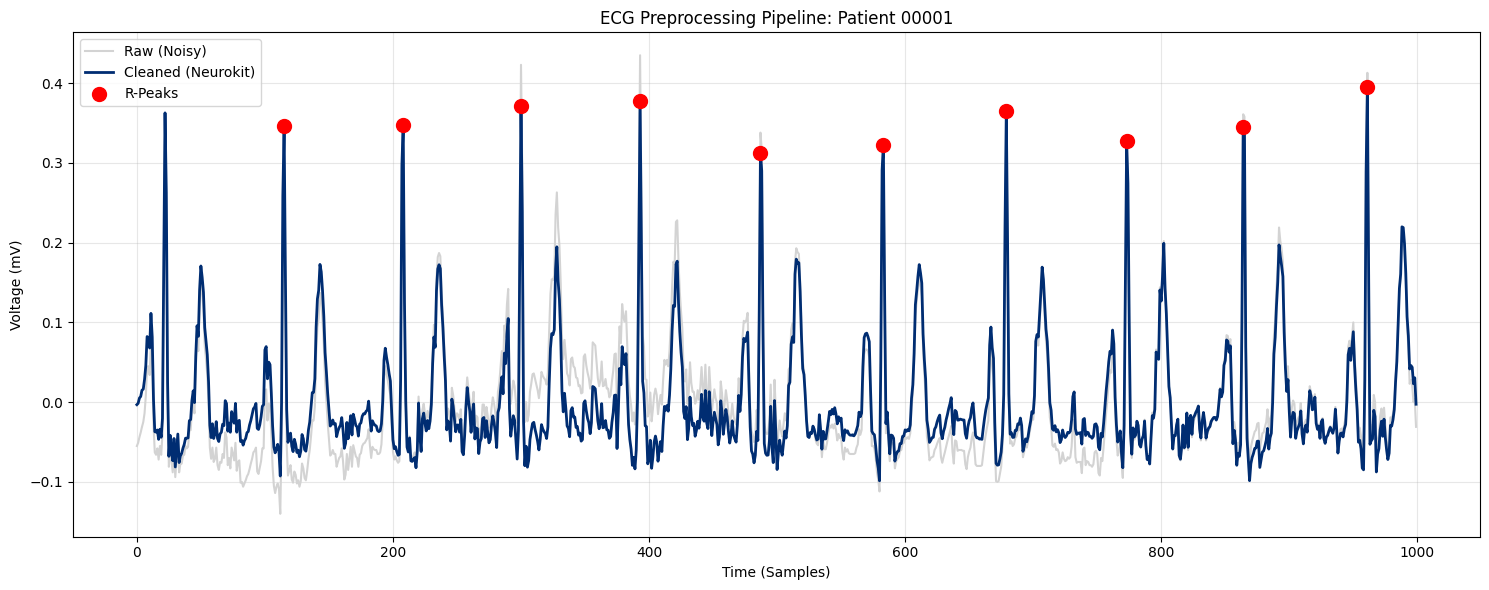

In [15]:
plt.figure(figsize=(15, 6))

# 1. Plot Raw (Faint background)
plt.plot(raw_signal[:2000], color='#d3d3d3', label='Raw (Noisy)')

# 2. Plot Clean (Dark Blue)
plt.plot(clean_signal[:2000], color='#002D72', linewidth=2, label='Cleaned (Neurokit)')

# 3. Plot Peaks (Red Dots)
# Filter peaks to only show the first 2000 samples
peaks_subset = r_peaks[r_peaks < 2000]
plt.scatter(peaks_subset, clean_signal[peaks_subset], color='red', s=100, zorder=5, label='R-Peaks')

plt.title("ECG Preprocessing Pipeline: Patient 00001")
plt.xlabel("Time (Samples)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save command
plt.savefig("ECG_Cleaning.png", dpi=150)
print("Plot saved as 'ECG_Cleaning.png'. Please download this for your report!")
plt.show()

##### ------------------------------------------
#### STEP 8: BATCH PROCESSING (The Bridge to ML)
##### ------------------------------------------
##### GOAL: Loop through all downloaded patients, extract features,
##### and save them to a CSV. This CSV will be the input for our ML model next lecture.

In [17]:
print("\n--- Starting Batch Processing ---")

# 1. Create an empty list to store results
dataset = []

for record in records:
    print(f"Processing {record}...")

    # A. Load
    data, meta = wfdb.rdsamp(f'data/{record}')
    sig = data[:, 1] # Lead II
    fs = meta['fs']

    # B. Process the ECG signal
    processed_signal, r_peaks_dict = nk.ecg_process(sig, sampling_rate=100)

    # D. Extract Features (The Magic Button)
    # This returns a DataFrame with 1 row
    features = nk.ecg_intervalrelated(processed_signal, sampling_rate=fs)

    # E. Add the 'ID' so we know who this is
    features['ID'] = record

    # F. Append to our list
    dataset.append(features)

# 3. Combine into one big DataFrame
final_df = pd.concat(dataset, ignore_index=True)

# 4. Move 'ID' to the first column for readability
cols = ['ID'] + [c for c in final_df.columns if c != 'ID']
final_df = final_df[cols]

# 5. Save to CSV
final_df.to_csv("ecg_features.csv", index=False)

print("\nSuccess! Saved 'ecg_features.csv'.")
print(final_df[['ID', 'HRV_RMSSD', 'ECG_Rate_Mean']])


--- Starting Batch Processing ---
Processing 00001_lr...
Processing 00103_lr...
Processing 00225_lr...

Success! Saved 'ecg_features.csv'.
         ID               HRV_RMSSD ECG_Rate_Mean
0  00001_lr  [[26.457513110645905]]     63.916476
1  00103_lr                [[10.0]]    104.913433
2  00225_lr  [[41.576092031014994]]     59.756057
